# XGB 预测个股收益、评估因子重要性（A 股面板）

In [1]:
import pandas as pd
import numpy as np

In [2]:
c=pd.read_parquet('D:/学习资料/数据/2016-2026数据.parquet')

In [3]:
#获取基础信息数据，获取基础信息数据，包括股票代码、名称、上市日期、退市日期等
#包括股票代码、上市状态、行业、上市日期等
#当前所有上市、退市的股票列表
stock_basic = pd.read_csv("D:/学习资料/数据/stock_basic3.csv")
stock_basic['list_date']=pd.to_datetime(stock_basic['list_date'])
# 预提取上市日期映射，后续直接匹配，减少merge开销
list_date_map = dict(zip(stock_basic["ts_code"], stock_basic["list_date"]))


In [4]:
#合并上市日期数据
c["list_date"] = c["ts_code"].map(list_date_map)

In [5]:
#查看缺失值
c.isna().sum()

ts_code                 0
trade_date              0
turnover_rate           0
volume_ratio        15975
pe                1473641
pe_ttm            1855797
pb                  64837
ps                   3351
ps_ttm               8069
float_share             0
total_mv                0
circ_mv                 0
limit_status      7665217
suspend_type     10315695
type             10029098
open                    0
high                    0
low                     0
close                   0
change                  0
pct_chg                 0
vol                     0
amount                  0
adj_factor              0
l1_code              3723
l1_name              3723
out_date         10315695
list_date            3723
dtype: int64

In [6]:
len(c)

10315695

In [7]:
c[c['suspend_type']=='S' ][['ts_code','trade_date','open','suspend_type','type']].head()

,ts_code,trade_date,open,suspend_type,type


In [8]:
c[['pct_chg','limit_status']].head()

,pct_chg,limit_status
0,-8.27,NaN
1,-10.00,NaN
2,-10.02,NaN
3,-3.58,NaN
4,-9.97,NaN


# 处理缺失值

# 看数据结构

In [9]:
c.columns

Index(['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'type', 'open', 'high', 'low', 'close',
       'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'l1_name', 'out_date', 'list_date'],
      dtype='str')

In [10]:
df=c[['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'type', 'open', 'high', 'low', 'close',
       'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'l1_name', 'out_date', 'list_date']]

In [11]:
df=df.rename(columns={'l1_name':'hangye','type':'st_type'})

In [12]:
df.columns

Index(['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'st_type', 'open', 'high', 'low',
       'close', 'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'hangye', 'out_date', 'list_date'],
      dtype='str')

# 开始处理

In [13]:
df['trade_date'] = pd.to_datetime(df['trade_date'])  # 日期
df['list_date'] = pd.to_datetime(df['list_date'])  # 日期

In [14]:
# 依据 股票代码+交易日 整体去重，保留第一条重复数据
df = df.drop_duplicates(subset=["ts_code", "trade_date"], keep="first")

In [15]:
len(df)

10135300

In [16]:
df.isna().sum()

ts_code                 0
trade_date              0
turnover_rate           0
volume_ratio        15794
pe                1451865
pe_ttm            1828445
pb                  63798
ps                   3315
ps_ttm               7892
float_share             0
total_mv                0
circ_mv                 0
limit_status      7527522
suspend_type     10135300
st_type           9853540
open                    0
high                    0
low                     0
close                   0
change                  0
pct_chg                 0
vol                     0
amount                  0
adj_factor              0
l1_code              3653
hangye               3653
out_date         10135300
list_date            3653
dtype: int64

In [17]:
#设置多重索引
df=df.set_index(['ts_code', 'trade_date'])

In [18]:
# 确保按股票代码分组后，按时间排序
df = df.sort_index(level=["ts_code", "trade_date"], ascending=[True, True])

In [19]:
#df['is_limit_up_down']=df['pct_chg'].apply(lambda x :1 if abs(x)>10 else 0)

#向量化运算
df['is_limit_up_down'] = np.where(np.abs(df['pct_chg']) > 10, 1, 0)

In [20]:
df.head(2)

turnover_rate  volume_ratio      pe  pe_ttm      pb  \
ts_code   trade_date                                                        
000001.SZ 2016-01-04         0.4774          0.98  8.1869  7.4202  1.0317   
          2016-01-05         0.5619          1.09  8.2375  7.4661  1.0381   

                          ps  ps_ttm   float_share      total_mv  \
ts_code   trade_date                                               
000001.SZ 2016-01-04  2.2085  1.8031  1.180405e+06  1.621173e+07   
          2016-01-05  2.2221  1.8143  1.180405e+06  1.631189e+07   

                           circ_mv  ...  change pct_chg        vol  \
ts_code   trade_date                ...                              
000001.SZ 2016-01-04  1.337399e+07  ...   -0.66   -5.50  563497.87   
          2016-01-05  1.345662e+07  ...    0.07    0.62  663269.95   

                           amount  adj_factor    l1_code  hangye  out_date  \
ts_code   trade_date                                                         
000001.SZ 2016-01-04  660376.1531      85.994  801780.SI      银行      None   
          2016-01-05  755531.3537      85.994  801780.SI      银行      None   

                                         list_date  is_limit_up_down  
ts_code   trade_date                                                  
000001.SZ 2016-01-04 1970-01-01 00:00:00.019910403                 0  
          2016-01-05 1970-01-01 00:00:00.019910403                 0  

[2 rows x 27 columns]

In [21]:
# 剔除上市日期为空的所有个股
all_null_mask = df.groupby(level="ts_code")["list_date"].transform(lambda x: x.isna().all())#" 先标记：每组(单只股票)list_date是否全部为空,都是 NaN 才删除；如果只是个别行空值，用下面方式填充同股票上市日期
df = df[~all_null_mask]
# 个股内部上市日期是固定不变值，个股内填充缺失的list_date
df["list_date"] = df.groupby(level="ts_code")["list_date"].transform("ffill").transform("bfill")
# 填充完依旧为空的股票彻底删掉
df = df[df["list_date"].notna()].copy()

In [22]:
#剔除上市90天内的股票数据
df=df[(df.index.get_level_values("trade_date")-df['list_date']).dt.days > 90]

In [23]:
# 剔除行业为空的所有个股
df = df.dropna(subset=["hangye"], how="all")#how="all"：该股票整条 list_date 都是 NaN 才删除；如果只是个别行空值，用下面方式填充同股票上市日期

# 个股内部上市日期是固定不变值，个股内填充缺失的list_date
df["hangye"] = df.groupby(level="ts_code")["hangye"].transform("ffill").transform("bfill")
# 填充完依旧为空的股票彻底删掉
df = df[df["hangye"].notna()].copy()

In [24]:
#得到后复权的价格
df['open']=df['open']*df['adj_factor']
df['high']=df['high']*df['adj_factor']
df['low']=df['low']*df['adj_factor']
df['close']=df['close']*df['adj_factor']

In [25]:
#个股内向前填充收盘价（维持时序连续）
df["close_fill"] = df.groupby(level="ts_code")["close"].ffill()######pandas 针对 pct_change / shift / diff / ffill / bfill 这类逐行时序运算，分组执行后自动保留原始完整多层索引、行数完全不变，
df["pe_fill"] = df.groupby(level="ts_code")["pe"].ffill()######
df["pe_ttm_fill"] = df.groupby(level="ts_code")["pe_ttm"].ffill()######
df["ps_fill"] = df.groupby(level="ts_code")["ps"].ffill()
df["ps_ttm_fill"] = df.groupby(level="ts_code")["ps_ttm"].ffill()
df["pb_fill"] = df.groupby(level="ts_code")["pb"].ffill()

In [26]:
#1 计算技术因子
def calculate_technical_factors(price_df):
    df = price_df.copy()
    
    # 计算过去收益率
    df['return_1d'] = df.groupby(level='ts_code')['close_fill'].pct_change()#############= (当前值 /n 期前的值) − 1
    df['return_5d'] = df.groupby(level='ts_code')['close_fill'].pct_change(5)
    df['return_20d'] = df.groupby(level='ts_code')['close_fill'].pct_change(20)#pct= (当前值−前一期值)/前一期值

    ##一、====计算动量/趋势类因子 Momentum
    #简单移动平均
    df["ma5"] = df.groupby(level="ts_code")["close_fill"].transform(lambda x: x.rolling(5).mean())
    df['ma20'] = df.groupby(level="ts_code")["close_fill"].rolling(20).mean().droplevel(0)
    
    #均线斜率（线性回归法）
    def rolling_linreg_slope(window_arr):
        # window_arr：滚动窗口内ma5序列, raw=True传入numpy数组
        x = np.arange(len(window_arr))
        reg = linregress(x, window_arr)
        return reg.slope
    
    win1 = 5  # 使用最近5根MA5做线性拟合求斜率
    win2 = 20  # 使用最近5根MA5做线性拟合求斜率
    
    df["ma5_slope_lr"] = (
        df.groupby(level="ts_code")["ma5"]
        .rolling(window=win1)
        .apply(rolling_linreg_slope, raw=True)
        .droplevel(0)
    )
    df["ma20_slope_lr"] = df.groupby(level="ts_code")["ma20"].rolling(window=win2).apply(rolling_linreg_slope, raw=True).droplevel(0)

    ##二、====计算反转类因子 Reversal
    #计算乖离率BIAS
    df['BIAS_ma5'] = df['close'] / df['ma5'] - 1
    df['BIAS_ma20'] = df['close'] / df['ma20'] - 1

    #三、波动率因子（Volatility）
    # 计算收益率滚动标准差（5/20日滚动标准差）
    df['volatility_5d'] = df.groupby(level='ts_code')['return_1d'].rolling(5).std().droplevel(0)
    df['volatility_20d'] = df.groupby(level='ts_code')['return_1d'].rolling(20).std().droplevel(0)

    ##四、====流动性因子
    # 计算换手率（假设有`volume`和`float_share`字段）
    df['turnover'] = df['vol'] / df['float_share']
    
    # ===================================删除因滚动计算产生的缺失值行===============================

    df=df.iloc[20:,:]

    return df

#2 计算基本面因子
'''
估值类：pe、pb、ps
盈利类：每股收益、净利润率、ROE
运营：资产周转率
成长：营收、资产、净利润、研发增长率
财务健康：资产负债率、流动、速动
'''



'\n估值类：pe、pb、ps\n盈利类：每股收益、净利润率、ROE\n运营：资产周转率\n成长：营收、资产、净利润、研发增长率\n财务健康：资产负债率、流动、速动\n'

In [27]:
jibenmian=['pe','pb','ps','pe_ttm','ps_ttm']
df = df.copy()
for col in jibenmian:
    mean=df.groupby(level='ts_code')[col].transform(lambda x :x.rolling(window=120, min_periods=1).mean())#半年内均值。设置 min_periods=1，有数据就计算均值
    df[col]=df[col].fillna(mean)

In [28]:
# 按个股统计每列缺失占比
na_ratio = df.groupby(level="ts_code")[jibenmian].apply(lambda x: x.isna().mean())
# na_ratio 行=股票代码，列=各个基本面指标，数值=缺失比例



In [29]:
na_ratio

,pe,pb,ps,pe_ttm,ps_ttm
ts_code,,,,,
000001.SZ,0.000000,0.0,0.0,0.000000,0.0
000002.SZ,0.029080,0.0,0.0,0.088542,0.0
000004.SZ,0.401257,0.0,0.0,0.405296,0.0
000005.SZ,0.165323,0.0,0.0,0.206653,0.0
000006.SZ,0.125378,0.0,0.0,0.125378,0.0
...,...,...,...,...,...
920978.BJ,0.000000,0.0,0.0,0.000000,0.0
920981.BJ,0.121514,0.0,0.0,0.081673,0.0
920982.BJ,0.000000,0.0,0.0,0.000000,0.0


In [30]:
# 设定阈值20%：任意一个基本面因子缺失超20%就剔除该股票
threshold = 0.2
# 找出满足：任一指标缺失率>0.2 的ts_code
drop_stocks = na_ratio.index[ (na_ratio > threshold).any(axis=1) ]

# 从原数据删掉这批股票
df = df.drop(drop_stocks, level="ts_code")#df 是多层索引：(ts_code, trade_date)，level 指定在第一层 ts_code 维度删除

In [31]:
# df有行业字段
#行业中位数填充
ind_median = df.groupby("hangye")[jibenmian].transform(lambda x: x.median())
df[jibenmian] = df[jibenmian].fillna(ind_median)

In [32]:
from scipy.stats import linregress

In [33]:
# 3合并因子并处理缺失值
# 计算技术因子
df = calculate_technical_factors(df)
# 对齐基本面因子
#aligned_finance = align_finance_factors(price_with_tech, raw_finance_df)
 
# 合并
#all_factors_df = price_with_tech.join(aligned_finance, how='left')

In [34]:
#技术因子列
feature_cols = ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover']

In [35]:
# 4. 定义目标变量：未来N日收益率（这里以未来5日收益率为例）
df['target_return_5d'] = df.groupby(level='ts_code')['close_fill'].shift(-5) / df['close_fill'] - 1


In [36]:
#==========================保留个股首次被标记为ST之前的全部数据，剔除ST当日及后续所有风险数据，规避风险股异常波动干扰；================
##获取每只股票首次ST日期
df["first_st_date"]  = df[df["st_type"].notna()]['st_type'].groupby(level="ts_code").transform(lambda x: x.index.get_level_values("trade_date").min())
 

####筛选：保留首次ST之前的数据；没有出现过ST的全部保留
# 条件解释：如果first_st_date为空（从未ST）条件自动为True
# 下面同样用索引日期做筛选
date_arr = df.index.get_level_values("trade_date")
mask = (date_arr < df["first_st_date"]) | df["first_st_date"].isna()
df = df[mask].copy()

In [37]:
#构造筛选条件
cond1 = ~df["suspend_type"].isin(['S'])       # 删除停牌
#########cond2 = ~(abs(daily_basic["pct_chg"])>=10)        # 预测不删除删除涨跌停+-10%

df = df[cond1]

In [38]:
#删除目标变量为NaN的行
df=df.dropna(subset=['target_return_5d'])

In [39]:
#技术因子缺失值用中位数填充
for col in feature_cols:
    med=df.groupby(level='ts_code')[col].transform('median')
    df[col]=df[col].fillna(med)
    #all_factors_df[col] = all_factors_df.groupby('stock_code')[col].transform(lambda x: x.fillna(x.median()))


In [40]:
df.isna().sum()

turnover_rate             0
volume_ratio          13039
pe                        0
pe_ttm                    0
pb                        0
ps                        0
ps_ttm                    0
float_share               0
total_mv                  0
circ_mv                   0
limit_status        5379690
suspend_type        7344844
st_type             7344844
open                      0
high                      0
low                       0
close                     0
change                    0
pct_chg                   0
vol                       0
amount                    0
adj_factor                0
l1_code                   0
hangye                    0
out_date            7344844
list_date                 0
is_limit_up_down          0
close_fill                0
pe_fill                8201
pe_ttm_fill           24064
ps_fill                   2
ps_ttm_fill               2
pb_fill                 553
return_1d                 1
return_5d                16
return_20d          

In [41]:
len(df)

7344844

In [42]:
print('数据准备完毕')

数据准备完毕


# 开始建模

In [43]:
all_fac_0= ['return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover','pe','pb','ps','pe_ttm','ps_ttm','total_mv','hangye']
all_fac= ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover','pe','pb','ps','pe_ttm','ps_ttm','total_mv','hangye']

In [44]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV,RandomizedSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score## 均方误差,平均绝对误差,拟合优度（0~1，越接近1拟合越好）

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [45]:
df1=df[all_fac].dropna().copy()

In [51]:
df1.isna().sum()

is_limit_up_down    0
return_1d           0
return_5d           0
return_20d          0
ma5                 0
ma20                0
ma5_slope_lr        0
ma20_slope_lr       0
BIAS_ma5            0
BIAS_ma20           0
volatility_5d       0
volatility_20d      0
turnover            0
pe                  0
pb                  0
ps                  0
pe_ttm              0
ps_ttm              0
total_mv            0
hangye              0
ln_cap              0
dtype: int64

In [47]:
df1['ln_cap']=np.log(df1['total_mv'])

In [48]:
# 1 去极值 MAD
#去极值
def qujizhi(s,n=3):
    med=s.median()
    mad=np.median(abs(s-med))
    low=med-n*1.4826*mad
    high=med+n*1.4826*mad
    s=s.clip(low,high)
    return s

for col in [col for col in all_fac_0 if col != "hangye"]:
    df1[col]=df1.groupby(level='trade_date')[col].transform(qujizhi)

In [49]:
#2 标准化

scaler = StandardScaler()

for col in [col for col in all_fac_0 if col != "hangye"]:
    df1[col]=scaler.fit_transform(df1[[col]])



In [50]:
#3 中性化
df2=df1.copy()
import statsmodels.api as sm


In [52]:
df2[df2['total_mv']<0]['total_mv']

ts_code    trade_date
000006.SZ  2016-01-27   -0.024050
           2016-01-28   -0.034874
           2016-06-13   -0.009617
           2016-06-14   -0.007813
           2018-04-03   -0.002400
                           ...   
920992.BJ  2025-12-18   -1.041069
           2025-12-19   -1.042491
           2025-12-22   -1.044559
           2025-12-23   -1.045723
           2025-12-24   -1.046757
Name: total_mv, Length: 4655409, dtype: float64

In [53]:
len(df2[df2['total_mv']<0]['total_mv'])

4655409

In [56]:
def zhongxing(df,fac_col):
    y=df[fac_col]
    dure=pd.get_dummies(df['hangye'],drop_first=True,dtype=np.float64)
    X_raws=pd.concat([dure,df['ln_cap']],axis=1)
    X=sm.add_constant(X_raws)
    ols_model=sm.OLS(y,X).fit()
    return ols_model.resid

#for col in all_fac_0:
    #df2[col]=df2.groupby(level='trade_date').apply(lambda day_df: zhongxing(day_df, col)).droplevel(0)

for col in [col for col in all_fac_0 if col != "hangye"]:
    df2[col]=df2.groupby(level='trade_date',group_keys=False).apply(lambda day_df: zhongxing(day_df,col))

In [57]:

fin_all_fac= ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover','pe','pb','ps','pe_ttm','ps_ttm']

In [60]:
# 准备特征X和目标y
X = df2[fin_all_fac].values###返回类型：numpy.ndarray（标准数组）
mask1=df.index.isin(df1.index)
y = df.loc[mask1, 'target_return_5d'].values
 
# 获取时间索引，用于划分
dates = df2.index.get_level_values('trade_date').unique().sort_values()
split_date = dates[int(len(dates) * 0.7)] # 例如，用前70%的时间段做训练，后30%做测试
 
train_mask = df2.index.get_level_values('trade_date') <= split_date#######布尔值
test_mask = df2.index.get_level_values('trade_date') > split_date
 
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
 
print(f"训练集样本数：{X_train.shape[0]}， 测试集样本数：{X_test.shape[0]}")

训练集样本数：4418704， 测试集样本数：2925731


In [61]:
# 定义参数分布
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5],
}
 
# 创建基础模型
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# 时序5折
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40, # 随机尝试的组合数
    cv=TimeSeriesSplit(n_splits=5), # 时间序列交叉验证
    scoring='neg_mean_squared_error', # 评分指标，负MSE
    verbose=2,
    random_state=42,
    n_jobs=-1
)


# 在训练集上拟合随机搜索
random_search.fit(X_train, y_train)
 
# 输出最佳参数和分数
print("最佳参数组合：", random_search.best_params_)
print("最佳交叉验证分数（负MSE）：", random_search.best_score_)
 
# 用最佳参数训练最终模型
best_model = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
最佳参数组合： {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
最佳交叉验证分数（负MSE）： -0.005336530856321001


In [74]:
# 在测试集上进行预测
y_test_pred = best_model.predict(X_test)
 
# 计算评估指标
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
# 计算IC（信息系数）：预测值与真实值的秩相关系数，常用在量化中
ic = np.corrcoef(y_test_pred, y_test)[0, 1]
 
print(f"测试集 MSE: {test_mse:.6f}")
print(f"测试集 MAE: {test_mae:.6f}")
print(f"测试集 IC: {ic:.4f}")
 


测试集 MSE: 0.005112
测试集 MAE: 0.045690
测试集 IC: 0.0588


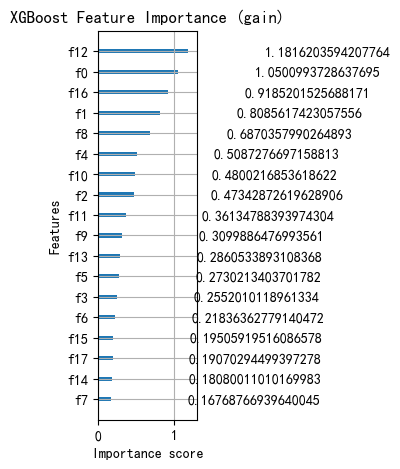

In [68]:
# 绘制特征重要性图
xgb.plot_importance(best_model, max_num_features=18, importance_type='gain') # weight/gain/cover
#分裂 Gain：一次分裂带来的目标函数下降值（误差减少量），总 Gain = 这个特征所有分裂点产生的 Gain 全部累加和
plt.title('XGBoost Feature Importance (gain)')
plt.tight_layout()
plt.show()

In [73]:
# 读取全部特征权重（包含0权重的f17）
score_dict = best_model.get_booster().get_score(importance_type="gain")
#训练送入的 X 矩阵是纯数组 / 无列名 DataFrame，XGBoost 的 sklearn 接口无法捕获字符串格式的特征名，feature_names_in_ 属性不存在，直接改用你手动定义的 fin_all_fac 列表遍历即可，不用读取模型内置名称。
#all_feature = best_model.feature_names_in_


# 循环打印所有特征gain，无贡献自动补0
for i in range(18):
    f_key = f"f{i}"
    gain_val = score_dict.get(f_key, 0.0)
    print(f"{f_key} | gain = {gain_val:.6f}")

f0 | gain = 1.050099
f1 | gain = 0.808562
f2 | gain = 0.473429
f3 | gain = 0.255201
f4 | gain = 0.508728
f5 | gain = 0.273021
f6 | gain = 0.218364
f7 | gain = 0.167688
f8 | gain = 0.687036
f9 | gain = 0.309989
f10 | gain = 0.480022
f11 | gain = 0.361348
f12 | gain = 1.181620
f13 | gain = 0.286053
f14 | gain = 0.180800
f15 | gain = 0.195059
f16 | gain = 0.918520
f17 | gain = 0.190703
